<a href="https://colab.research.google.com/github/SentineNet-AI-SpringBoard/SentinelNet-AI/blob/SENTINELNET-AI-KUSHAGRA/milestone4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/collab sentinl net ai/Wednesday-workingHours.pcap_ISCX.csv')
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN



#Simulate real-time predictions

In [12]:
X = df.drop('Label', axis=1)
y = df['Label']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (692703, 78)
Target (y) shape: (692703,)


In [11]:
print(df.columns)

# Based on the error and the common issue with CSVs, let's assume the column might have a space.
# We will use .str.strip() to clean column names first if necessary, or manually check.
# Upon inspection of the `df.head()` output, 'Label' is indeed the column name.
# Let's retry dropping 'Label' and selecting it for y. If it still fails, it implies a more subtle character issue.

# First, clean column names of any leading/trailing spaces
df.columns = df.columns.str.strip()

X = df.drop('Label', axis=1)
y = df['Label']

# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

In [13]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# 1. Convert the categorical target variable y_train to numerical labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Original y_train unique values:", y_train.unique())
print("Encoded y_train unique values:", np.unique(y_train_encoded))

# 2. Identify and handle any non-numeric or infinite values within X_train

# Convert columns that should be numeric but might contain non-numeric strings to numeric, coercing errors to NaN
# The previous df.head() output showed 'Flow Bytes/s' and 'Flow Packets/s' as potential candidates.
for col in ['Flow Bytes/s', ' Flow Packets/s']:
    if col in X_train.columns:
        X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
        X_test[col] = pd.to_numeric(X_test[col], errors='coerce')


# Fill NaN values (resulting from conversion or missing data) with 0 or a suitable strategy
X_train.fillna(0, inplace=True)
X_test.fillna(0, inplace=True)

# Replace infinite values with NaN, then fill NaN values (which could include the former infinite values)
# This is done for both X_train and X_test to maintain consistency
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

X_train.fillna(0, inplace=True)
X_test.fillna(0, inplace=True)

print("X_train after handling non-numeric and infinite values. Shape:", X_train.shape)
print("X_test after handling non-numeric and infinite values. Shape:", X_test.shape)

# Check if any non-numeric columns remain in X_train (excluding 'Label' if it was accidentally kept)
non_numeric_cols_X_train = X_train.select_dtypes(include=np.number).columns
if len(non_numeric_cols_X_train) != X_train.shape[1]:
    print("Warning: Some non-numeric columns might still be present in X_train. Review data types.")
    print(X_train.select_dtypes(exclude=np.number).columns)


Original y_train unique values: ['DoS Hulk' 'BENIGN' 'DoS GoldenEye' 'DoS slowloris' 'DoS Slowhttptest'
 'Heartbleed']
Encoded y_train unique values: [0 1 2 3 4 5]
X_train after handling non-numeric and infinite values. Shape: (484892, 78)
X_test after handling non-numeric and infinite values. Shape: (207811, 78)


# import `RandomForestClassifier`, instantiate it, and train the model using `X_train` and `y_train_encoded` to establish the prediction model.



In [14]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate the RandomForestClassifier model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available cores

# Train the model
print("Training RandomForestClassifier model...")
rf_model.fit(X_train, y_train_encoded)

print("RandomForestClassifier model training complete.")

Training RandomForestClassifier model...
RandomForestClassifier model training complete.


In [15]:
print("Simulating real-time predictions with batch processing...")

# Make predictions on the entire X_test DataFrame in a single call
real_time_predictions = rf_model.predict(X_test)

print("Real-time prediction simulation complete.")
print("Shape of real_time_predictions:", real_time_predictions.shape)
print("First 10 real-time predictions:", real_time_predictions[:10])

Simulating real-time predictions with batch processing...
Real-time prediction simulation complete.
Shape of real_time_predictions: (207811,)
First 10 real-time predictions: [0 0 2 2 0 0 2 0 2 2]


In [16]:
print("Decoding numerical predictions back to original labels...")

# Decode the numerical predictions back into their original string labels
decoded_predictions = label_encoder.inverse_transform(real_time_predictions)

print("Decoding complete.")
print("First 10 decoded real-time predictions:")
print(decoded_predictions[:10])

Decoding numerical predictions back to original labels...
Decoding complete.
First 10 decoded real-time predictions:
['BENIGN' 'BENIGN' 'DoS Hulk' 'DoS Hulk' 'BENIGN' 'BENIGN' 'DoS Hulk'
 'BENIGN' 'DoS Hulk' 'DoS Hulk']


#Intrusion Events and Generate Alerts



In [17]:
import pandas as pd

print("Identifying intrusion events...")

# Create a boolean mask for non-'BENIGN' predictions
intrusion_mask = (decoded_predictions != 'BENIGN')

# Filter decoded_predictions to get only intrusion labels
intrusion_labels = decoded_predictions[intrusion_mask]

# Filter X_test to get features corresponding to intrusion events
intrusion_features = X_test[intrusion_mask]

print(f"Total intrusion events detected: {len(intrusion_labels)}")
print("Displaying the first 10 intrusion alerts:")

# Display the first 10 intrusion events with their features
for i in range(min(10, len(intrusion_labels))):
    print(f"\n--- Intrusion Event {i+1} ---")
    print(f"Predicted Label: {intrusion_labels[i]}")
    print("Features:\n" + str(intrusion_features.iloc[i]))

if len(intrusion_labels) == 0:
    print("No intrusion events detected in the sample.")


Identifying intrusion events...
Total intrusion events detected: 75808
Displaying the first 10 intrusion alerts:

--- Intrusion Event 1 ---
Predicted Label: DoS Hulk
Features:
Destination Port                     80.0
Flow Duration                  86901737.0
Total Fwd Packets                     7.0
Total Backward Packets                5.0
Total Length of Fwd Packets         362.0
                                  ...    
Active Min                            5.0
Idle Mean                      85900000.0
Idle Std                              0.0
Idle Max                       85900000.0
Idle Min                       85900000.0
Name: 247769, Length: 78, dtype: float64

--- Intrusion Event 2 ---
Predicted Label: DoS Hulk
Features:
Destination Port                     80.0
Flow Duration                  85152215.0
Total Fwd Packets                     4.0
Total Backward Packets                5.0
Total Length of Fwd Packets         355.0
                                  ...    
Active

In [18]:
import pandas as pd

print("Preparing intrusion alerts for tabular storage...")

# Create a DataFrame for intrusion labels, ensuring its index aligns with intrusion_features
# intrusion_features already has the correct index from X_test filtering
intrusion_labels_series = pd.Series(intrusion_labels, index=intrusion_features.index, name='Predicted Label')

# Concatenate the intrusion features DataFrame with the intrusion labels Series
intrusion_alerts_df = pd.concat([intrusion_features, intrusion_labels_series], axis=1)

print("Intrusion alerts DataFrame created.")
print("Head of the intrusion_alerts_df:")
print(intrusion_alerts_df.head())

Preparing intrusion alerts for tabular storage...
Intrusion alerts DataFrame created.
Head of the intrusion_alerts_df:
        Destination Port  Flow Duration  Total Fwd Packets  \
247769                80       86901737                  7   
151574                80       85152215                  4   
261025                80      116371440                  7   
221736                80              4                  2   
115699                80       85150710                  5   

        Total Backward Packets  Total Length of Fwd Packets  \
247769                       5                          362   
151574                       5                          355   
261025                       7                          341   
221736                       0                            0   
115699                       8                          314   

        Total Length of Bwd Packets  Fwd Packet Length Max  \
247769                        11595                    362   
15157

#CSV


In [19]:
print("Saving intrusion alerts to 'intrusion_alerts.csv'...")

intrusion_alerts_df.to_csv('intrusion_alerts.csv', index=False)

print("Intrusion alerts saved successfully.")

Saving intrusion alerts to 'intrusion_alerts.csv'...
Intrusion alerts saved successfully.


#Text File



In [20]:
print("Saving intrusion alerts to 'intrusion_alerts.txt'...")

# Open a new text file named 'intrusion_alerts.txt' in write mode
with open('intrusion_alerts.txt', 'w') as f:
    # Iterate through each row of the intrusion_alerts_df DataFrame
    for index, row in intrusion_alerts_df.iterrows():
        # Write a separator for each alert
        f.write("--- Intrusion Alert ---\n")

        # Write the predicted label
        predicted_label = row['Predicted Label']
        f.write(f"Predicted Label: {predicted_label}\n")

        # Write the feature values, excluding the 'Predicted Label'
        for col_name, value in row.drop('Predicted Label').items():
            f.write(f"{col_name}: {value}\n")
        f.write("\n") # Add an extra newline for readability between alerts

print("Intrusion alerts saved successfully to 'intrusion_alerts.txt'.")

Saving intrusion alerts to 'intrusion_alerts.txt'...
Intrusion alerts saved successfully to 'intrusion_alerts.txt'.


#Dashboard



Generating bar chart for intrusion type distribution...


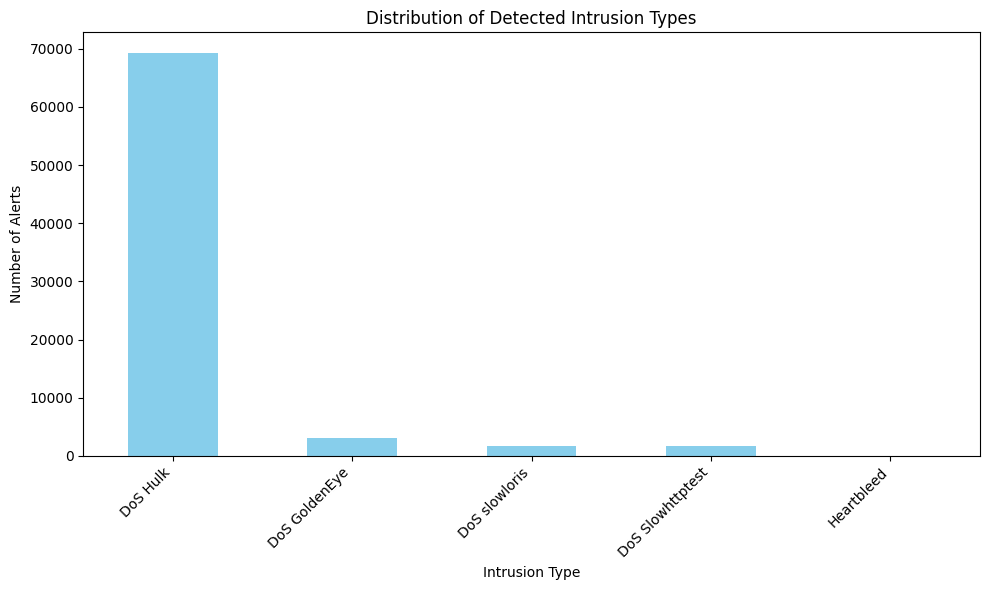

Bar chart generated.


In [21]:
import matplotlib.pyplot as plt

print("Generating bar chart for intrusion type distribution...")

# Calculate the value counts of the 'Predicted Label' column
intrusion_type_distribution = intrusion_alerts_df['Predicted Label'].value_counts()

# Create a bar chart
plt.figure(figsize=(10, 6)) # Adjust figure size for better readability
intrusion_type_distribution.plot(kind='bar', color='skyblue')

# Add labels and title
plt.xlabel('Intrusion Type')
plt.ylabel('Number of Alerts')
plt.title('Distribution of Detected Intrusion Types')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right') # 'ha' for horizontal alignment

# Ensure layout is tight to prevent labels from overlapping
plt.tight_layout()

# Display the plot
plt.show()

print("Bar chart generated.")